# Import de Dados e Libs

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
base_c_nulos = False

if base_c_nulos:
    PATH_FILE = "../dados/bruto/base_consolidada.csv"
else:
    PATH_FILE = "../dados/tratado/consolidado_sem_nulos.csv"



if base_c_nulos:
    PATH_TO_SAVE = "../resultados/base_c_vazios/"
else:
    PATH_TO_SAVE = "../resultados/base_tratada/"

In [24]:
df = pd.read_csv(
    PATH_FILE,
    index_col=0
)

df.index = pd.to_datetime(df.index)

In [25]:
df.columns

Index(['Selic', 'IPCA', 'PIB', 'Exportacoes', 'Importacoes', 'FEDFUNDS',
       'IBOV', 'SP500', 'Petroleo', 'USD/BRL'],
      dtype='str')

In [26]:
print(df["FEDFUNDS"].head())
print(df["FEDFUNDS"].dtype)
print(df["FEDFUNDS"].isna().sum())

2016-05-02    0.37
2016-05-03    0.37
2016-05-04    0.37
2016-05-05    0.37
2016-05-06    0.37
Name: FEDFUNDS, dtype: float64
float64
0


In [27]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2601 entries, 2016-05-02 to 2026-04-30
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Selic        2601 non-null   float64
 1   IPCA         2601 non-null   float64
 2   PIB          2601 non-null   float64
 3   Exportacoes  2601 non-null   float64
 4   Importacoes  2601 non-null   float64
 5   FEDFUNDS     2601 non-null   float64
 6   IBOV         2601 non-null   float64
 7   SP500        2601 non-null   float64
 8   Petroleo     2601 non-null   float64
 9   USD/BRL      2601 non-null   float64
dtypes: float64(10)
memory usage: 223.5 KB


In [28]:
print(df[["USD/BRL", "FEDFUNDS"]].head(20))

            USD/BRL  FEDFUNDS
2016-05-02   3.4328      0.37
2016-05-03   3.4965      0.37
2016-05-04   3.5549      0.37
2016-05-05   3.5454      0.37
2016-05-06   3.5331      0.37
2016-05-09   3.4990      0.37
2016-05-10   3.5130      0.37
2016-05-11   3.4704      0.37
2016-05-12   3.4470      0.37
2016-05-13   3.4771      0.37
2016-05-16   3.5302      0.37
2016-05-17   3.4945      0.37
2016-05-18   3.4861      0.37
2016-05-19   3.5585      0.37
2016-05-20   3.5609      0.37
2016-05-23   3.5573      0.37
2016-05-24   3.5665      0.37
2016-05-25   3.5673      0.37
2016-05-26   3.5769      0.37
2016-05-27   3.5827      0.37


# Funções Auxiliares

In [29]:
PATH_GRAFICOS = f"{PATH_TO_SAVE}/graficos/"

In [30]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns


def plot_serie_temporal(
    df,
    coluna,
    titulo,
    ylabel,
    figsize=(14, 6),
    mostrar_media=False,
    formato_data="%Y",
    salvar=False,
    nome_arquivo="grafico.png"
):
    """
    Plota uma série temporal com estilo adequado para trabalhos acadêmicos.

    Parâmetros
    ----------
    df : pandas.DataFrame
        DataFrame contendo a série temporal.

    coluna : str
        Nome da coluna que será plotada.

    titulo : str
        Título do gráfico.

    ylabel : str
        Rótulo do eixo Y.

    figsize : tuple
        Dimensões da figura.

    mostrar_media : bool
        Se True, adiciona uma linha representando a média da série.

    formato_data : str
        Formato das datas no eixo X.

    salvar : bool
        Se True, salva o gráfico em arquivo.

    nome_arquivo : str
        Nome do arquivo de saída.
    """

    # Configuração do estilo
    sns.set_theme(
        style="whitegrid",
        context="notebook",
        font_scale=1.1
    )

    # Criação da figura
    fig, ax = plt.subplots(figsize=figsize)

    # Série temporal
    ax.plot(
        df.index,
        df[coluna],
        linewidth=1.8,
        label=coluna
    )

    # Título
    ax.set_title(
        titulo,
        fontsize=16,
        fontweight="bold",
        pad=15
    )

    # Eixos
    ax.set_xlabel("Data", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)

    # Formatação das datas
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(
        mdates.DateFormatter(formato_data)
    )

    # Grade horizontal
    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.4
    )

    # Remove grade vertical
    ax.grid(axis="x", visible=False)

    # Remove bordas
    sns.despine(
        ax=ax,
        top=True,
        right=True
    )

    # Média
    if mostrar_media:
        media = df[coluna].mean()

        ax.axhline(
            media,
            linestyle="--",
            linewidth=1.2,
            label=f"Média: {media:.2f}"
        )

    # Legenda
    ax.legend(
        frameon=False,
        loc="upper left"
    )

    # Ajuste
    plt.tight_layout()

    # Salvar
    if salvar:
        plt.savefig(
            f"{PATH_GRAFICOS}{nome_arquivo}",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

In [31]:
def plot_variaveis_temporais(
    df,
    colunas,
    titulos=None,
    n_colunas=2,
    figsize_por_grafico=(7, 4),
    formato_data="%Y",
    salvar=False,
    mostrar_media=False,
    nome_arquivo="variaveis_temporais.png"
):
    """
    Plota múltiplas séries temporais em subplots.

    Cada variável possui seu próprio eixo Y.
    """

    sns.set_theme(
        style="whitegrid",
        context="notebook",
        font_scale=1.0
    )

    n_graficos = len(colunas)
    n_linhas = (n_graficos + n_colunas - 1) // n_colunas

    fig, axes = plt.subplots(
        n_linhas,
        n_colunas,
        figsize=(
            figsize_por_grafico[0] * n_colunas,
            figsize_por_grafico[1] * n_linhas
        ),
        squeeze=False
    )

    axes = axes.flatten()

    if titulos is None:
        titulos = colunas

    for i, coluna in enumerate(colunas):

        ax = axes[i]

        ax.plot(
            df.index,
            df[coluna],
            linewidth=1.5
        )

        ax.set_title(
            titulos[i],
            fontsize=12,
            fontweight="bold"
        )

        ax.set_xlabel("Data")
        ax.set_ylabel(coluna)

        ax.xaxis.set_major_locator(
            mdates.AutoDateLocator()
        )

        ax.xaxis.set_major_formatter(
            mdates.DateFormatter(formato_data)
        )

    # Média
        if mostrar_media:
            media = df[coluna].mean()

            ax.axhline(
                media,
                linestyle="--",
                linewidth=1.2,
                label=f"Média: {media:.2f}"
            )
            # Legenda
            ax.legend(
                frameon=False,
                loc="upper left"
            )

        ax.grid(
            axis="y",
            linestyle="--",
            alpha=0.35
        )

        ax.grid(axis="x", visible=False)

        sns.despine(
            ax=ax,
            top=True,
            right=True
        )

    # Remove subplots vazios
    for i in range(n_graficos, len(axes)):
        fig.delaxes(axes[i])

    fig.suptitle(
        "Evolução temporal das principais variáveis explicativas",
        fontsize=16,
        fontweight="bold",
        y=1.02
    )

    plt.tight_layout()

    if salvar:
        plt.savefig(
            f"{PATH_GRAFICOS}{nome_arquivo}",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

In [32]:
def plot_distribuicao(
    df,
    coluna,
    titulo,
    xlabel,
    bins=30,
    figsize=(10, 6),
    salvar=False,
    nome_arquivo="distribuicao.png"
):
    """
    Plota histograma e curva de densidade de uma variável.
    """

    sns.set_theme(
        style="whitegrid",
        context="notebook",
        font_scale=1.1
    )

    fig, ax = plt.subplots(figsize=figsize)

    sns.histplot(
        data=df,
        x=coluna,
        bins=bins,
        kde=True,
        ax=ax
    )

    ax.set_title(
        titulo,
        fontsize=16,
        fontweight="bold",
        pad=15
    )

    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel("Frequência", fontsize=12)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.4
    )

    ax.grid(axis="x", visible=False)

    sns.despine(
        ax=ax,
        top=True,
        right=True
    )

    plt.tight_layout()

    if salvar:
        plt.savefig(
            f"{PATH_GRAFICOS}{nome_arquivo}",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

In [33]:
from sklearn.preprocessing import StandardScaler


def plot_boxplots_padronizados(
    df,
    colunas,
    titulo="Boxplots das variáveis padronizadas",
    figsize=(12, 6),
    salvar=False,
    nome_arquivo="boxplots.png"
):
    """
    Plota boxplots de variáveis após padronização.

    A padronização é feita individualmente para cada variável:
    
        z = (x - média) / desvio padrão
    """

    sns.set_theme(
        style="whitegrid",
        context="notebook",
        font_scale=1.0
    )

    dados = df[colunas].dropna()

    scaler = StandardScaler()

    dados_padronizados = scaler.fit_transform(dados)

    dados_padronizados = pd.DataFrame(
        dados_padronizados,
        columns=colunas,
        index=dados.index
    )

    dados_long = dados_padronizados.melt(
        var_name="Variável",
        value_name="Valor padronizado"
    )

    fig, ax = plt.subplots(figsize=figsize)

    sns.boxplot(
        data=dados_long,
        x="Variável",
        y="Valor padronizado",
        ax=ax
    )

    ax.set_title(
        titulo,
        fontsize=16,
        fontweight="bold",
        pad=15
    )

    ax.set_xlabel("")
    ax.set_ylabel("Valor padronizado (z-score)")

    ax.tick_params(axis="x", rotation=45)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.4
    )

    ax.grid(axis="x", visible=False)

    sns.despine(
        ax=ax,
        top=True,
        right=True
    )

    plt.tight_layout()

    if salvar:
        plt.savefig(
            f"{PATH_GRAFICOS}{nome_arquivo}",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

In [34]:
def plot_matriz_correlacao(
    df,
    colunas=None,
    titulo="Matriz de correlação das variáveis",
    figsize=(10, 8),
    salvar=False,
    nome_arquivo="matriz_correlacao.png"
):
    """
    Plota uma matriz de correlação utilizando heatmap.
    """

    sns.set_theme(
        style="white",
        context="notebook",
        font_scale=1.0
    )

    if colunas is not None:
        dados = df[colunas]
    else:
        dados = df

    correlacao = dados.corr()

    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        correlacao,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        cbar_kws={
            "label": "Correlação de Pearson"
        },
        ax=ax
    )

    ax.set_title(
        titulo,
        fontsize=16,
        fontweight="bold",
        pad=15
    )

    plt.tight_layout()

    if salvar:
        plt.savefig(
            f"{PATH_GRAFICOS}{nome_arquivo}",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

In [35]:
def plot_scatter_relacoes(
    df,
    variavel_alvo,
    variaveis_explicativas,
    n_colunas=2,
    figsize_por_grafico=(7, 5),
    adicionar_regressao=True,
    salvar=False,
    nome_arquivo="scatterplots.png"
):
    """
    Plota scatterplots entre uma variável alvo e
    múltiplas variáveis explicativas.
    """

    sns.set_theme(
        style="whitegrid",
        context="notebook",
        font_scale=1.0
    )

    n_graficos = len(variaveis_explicativas)

    n_linhas = (
        n_graficos + n_colunas - 1
    ) // n_colunas

    fig, axes = plt.subplots(
        n_linhas,
        n_colunas,
        figsize=(
            figsize_por_grafico[0] * n_colunas,
            figsize_por_grafico[1] * n_linhas
        ),
        squeeze=False
    )

    axes = axes.flatten()

    for i, variavel in enumerate(variaveis_explicativas):

        ax = axes[i]

        if adicionar_regressao:

            sns.regplot(
                data=df,
                x=variavel,
                y=variavel_alvo,
                scatter_kws={
                    "alpha": 0.5,
                    "s": 30
                },
                line_kws={
                    "linewidth": 2
                },
                ax=ax
            )

        else:

            sns.scatterplot(
                data=df,
                x=variavel,
                y=variavel_alvo,
                alpha=0.5,
                s=30,
                ax=ax
            )

        ax.set_title(
            f"{variavel_alvo} × {variavel}",
            fontsize=12,
            fontweight="bold"
        )

        ax.set_xlabel(variavel)
        ax.set_ylabel(variavel_alvo)

        ax.grid(
            linestyle="--",
            alpha=0.35
        )

        sns.despine(
            ax=ax,
            top=True,
            right=True
        )

    # Remove espaços vazios
    for i in range(n_graficos, len(axes)):
        fig.delaxes(axes[i])

    fig.suptitle(
        f"Relação entre {variavel_alvo} e principais variáveis explicativas",
        fontsize=16,
        fontweight="bold",
        y=1.02
    )

    plt.tight_layout()

    if salvar:
        plt.savefig(
            f"{PATH_GRAFICOS}{nome_arquivo}",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

# Análises

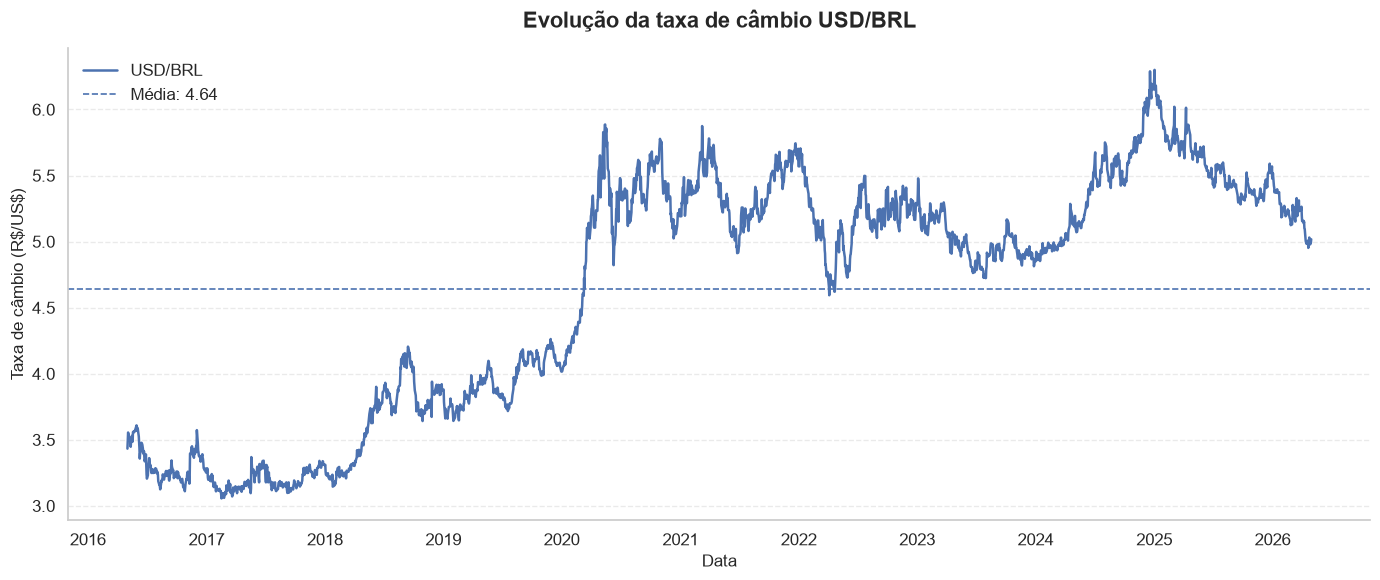

In [36]:
plot_serie_temporal(
    df=df,
    coluna="USD/BRL",
    titulo="Evolução da taxa de câmbio USD/BRL",
    ylabel="Taxa de câmbio (R\$/US\$)",
    mostrar_media=True,
    salvar=True,
    nome_arquivo="figura_1_Evolucao_taxa_cambio.png"
)

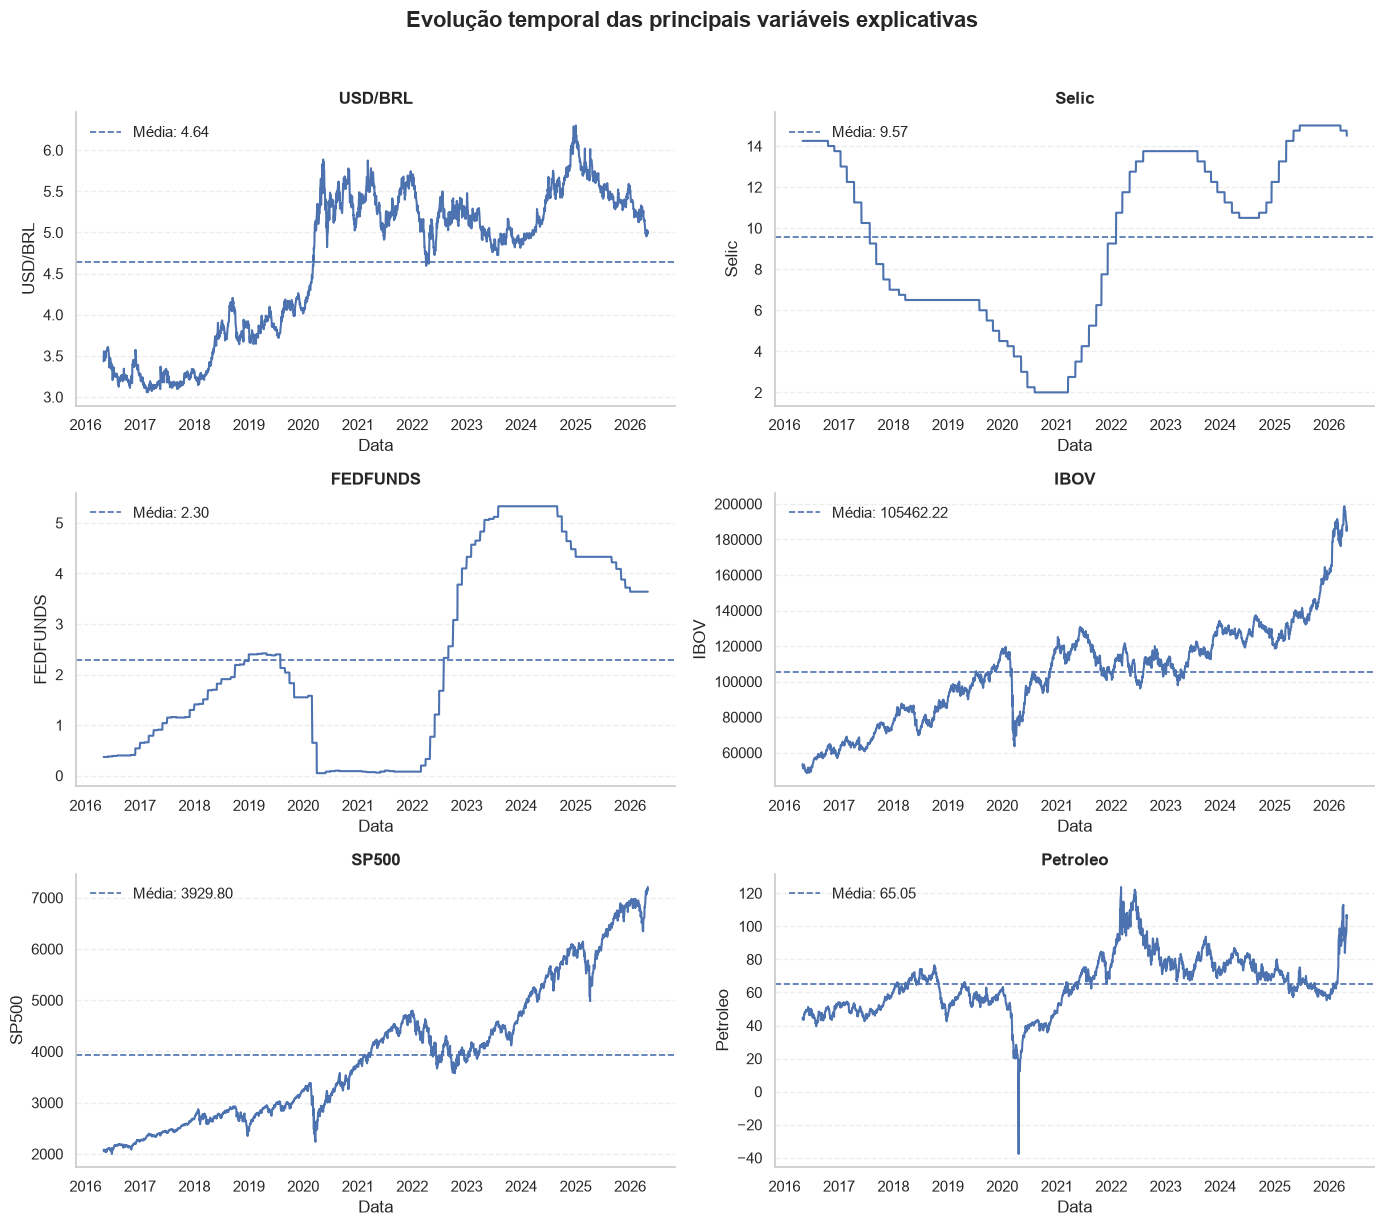

In [37]:
variaveis = [
    "USD/BRL",
    "Selic",
    "FEDFUNDS",
    "IBOV",
    "SP500",
    "Petroleo"
]

df_plot = df.copy()

df_plot["FEDFUNDS"] = df_plot["FEDFUNDS"].ffill()

plot_variaveis_temporais(
    df=df_plot,
    colunas=variaveis,
    salvar=True,
    mostrar_media=True,
    nome_arquivo="figura_2_variaveis_explicativas.png"
)

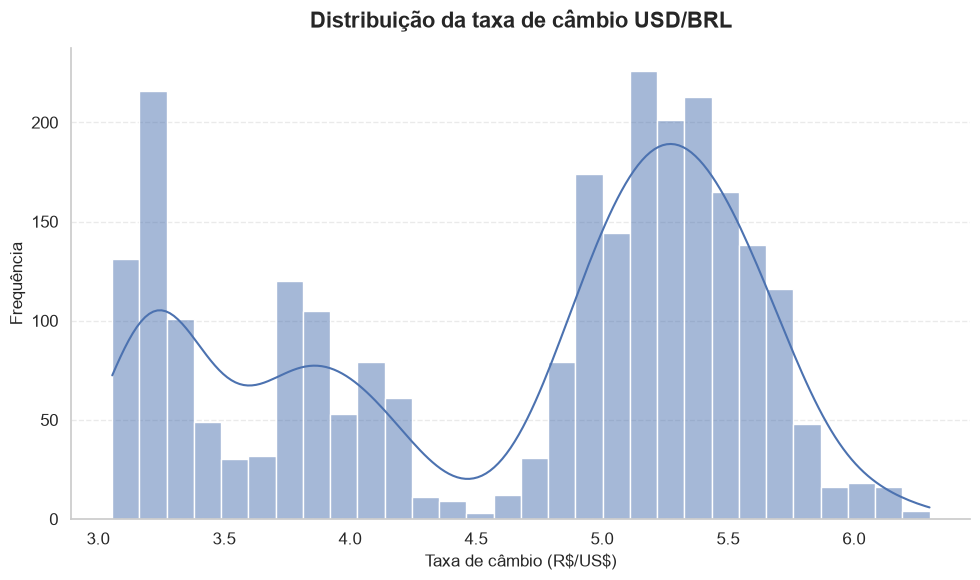

In [38]:
plot_distribuicao(
    df=df,
    coluna="USD/BRL",
    titulo="Distribuição da taxa de câmbio USD/BRL",
    xlabel="Taxa de câmbio (R\$/US\$)",
    salvar=True,
    nome_arquivo="figura_3_distribuicao_usd_brl.png"
)

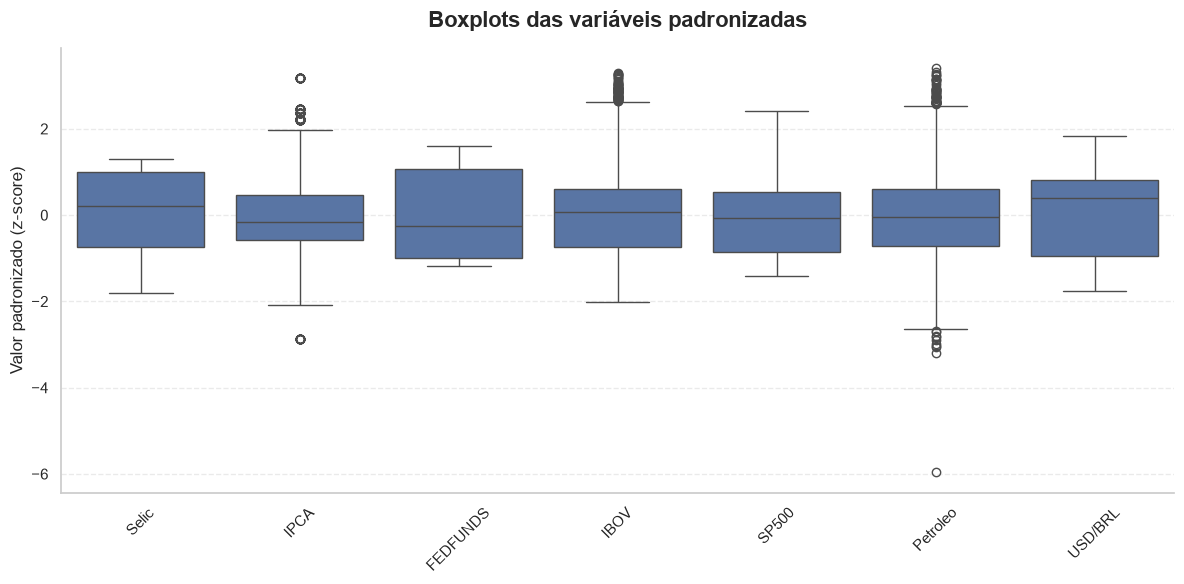

In [39]:
variaveis = [
    "Selic",
    "IPCA",
    "FEDFUNDS",
    "IBOV",
    "SP500",
    "Petroleo",
    "USD/BRL"
]

plot_boxplots_padronizados(
    df=df,
    colunas=variaveis,
    salvar=True,
    nome_arquivo="figura_4_boxplots.png"
)

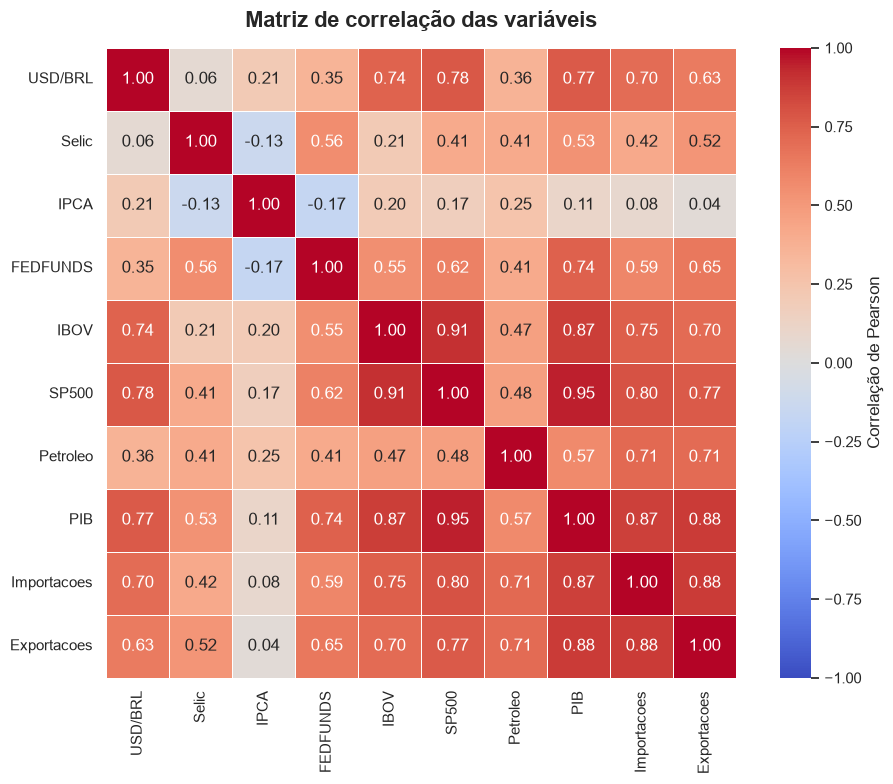

In [40]:
variaveis = [
    "USD/BRL",
    "Selic",
    "IPCA",
    "FEDFUNDS",
    "IBOV",
    "SP500",
    "Petroleo",
    "PIB",
    "Importacoes",
    "Exportacoes"
]

plot_matriz_correlacao(
    df=df,
    colunas=variaveis,
    salvar=True,
    nome_arquivo="figura_5_correlacao.png"
)

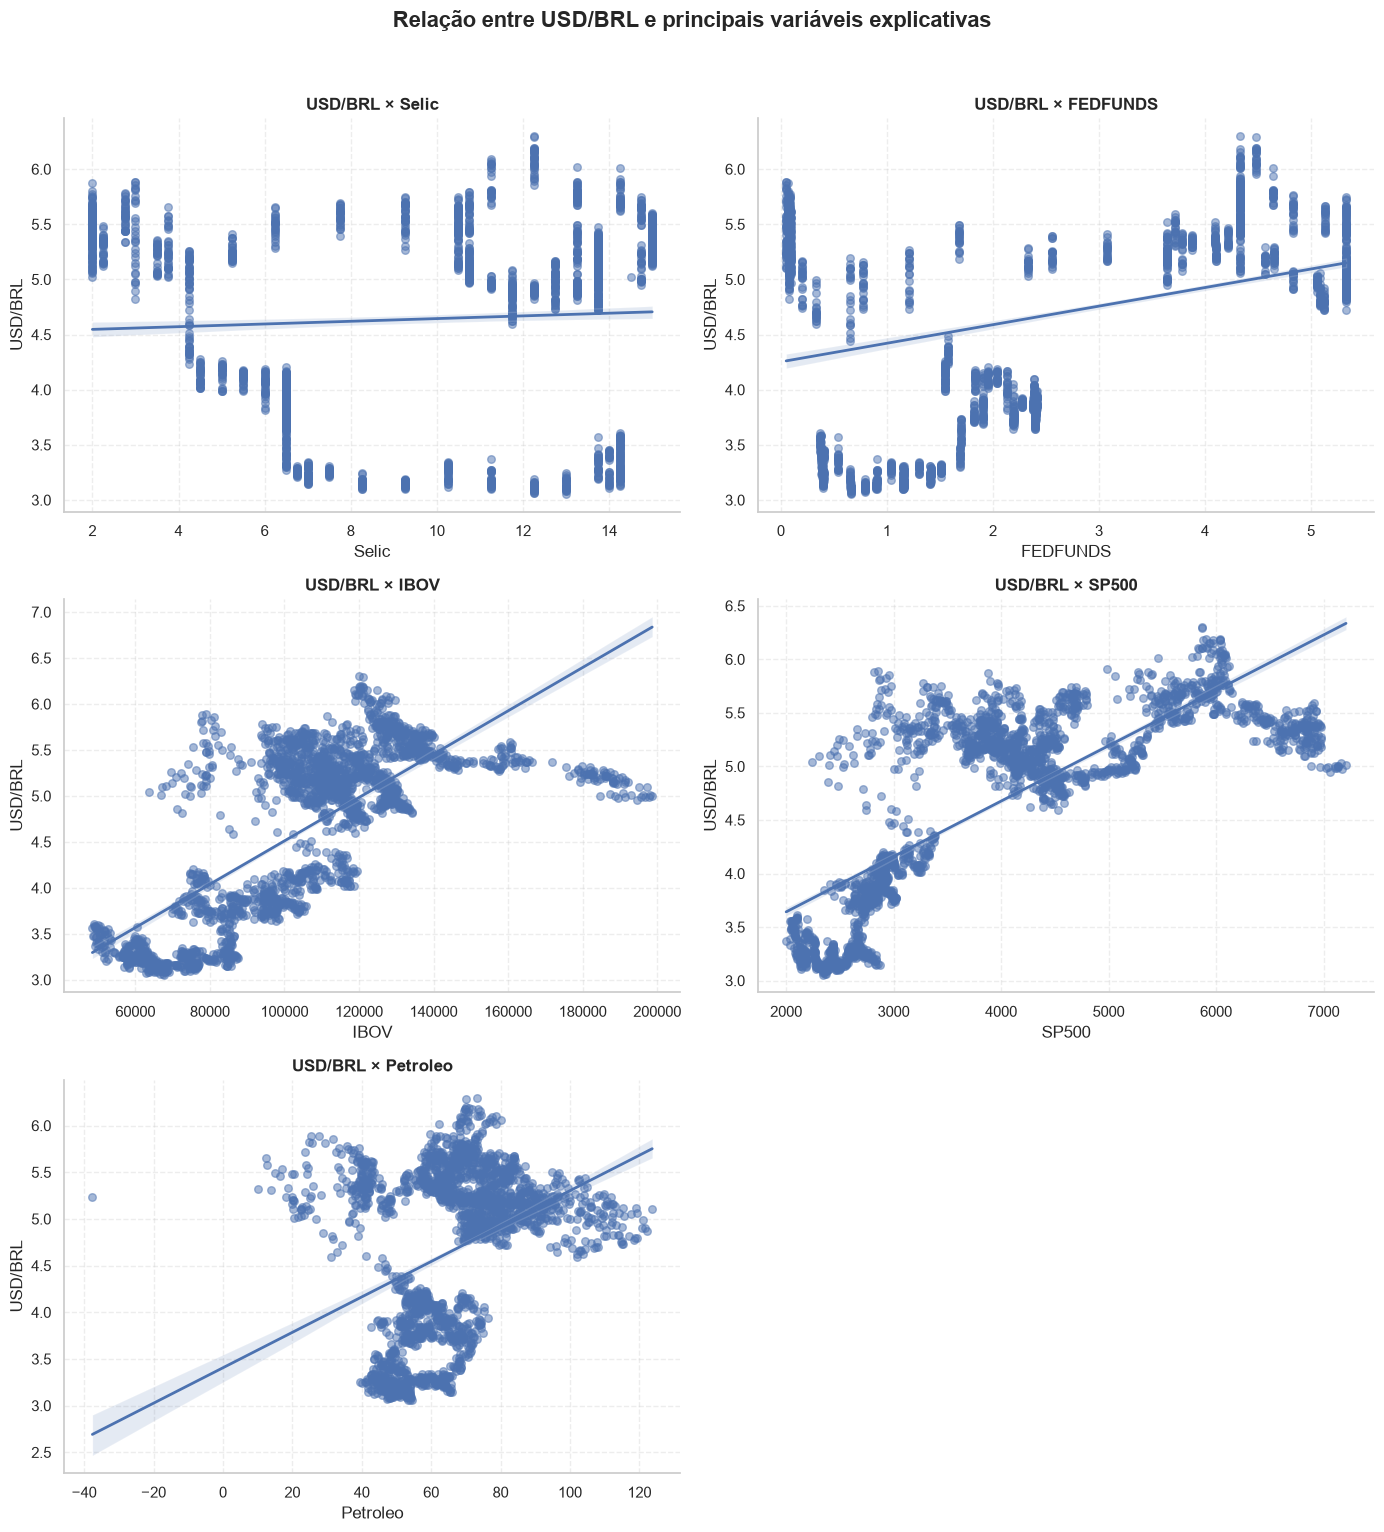

In [41]:
variaveis = [
   
    "Selic",
    "FEDFUNDS",
    "IBOV",
    "SP500",
    "Petroleo"
]

plot_scatter_relacoes(
    df=df,
    variavel_alvo="USD/BRL",
    variaveis_explicativas=variaveis,
    salvar=True,
    nome_arquivo="figura_6_scatterplots.png"
)